# 02_02 - Weather Data: Exploratory Data Analysis (EDA)

## 1. Objective and Business Rationale

This notebook explores the aggregated national weather dataset (`national_weather_aggregated.csv`) generated by our processing engine. 

For our **Operational Shield** (the Reinforcement Learning agent), weather acts as the primary exogenous driver for price volatility in the Iberian Energy Market (OMIE/OMIP). We analyze the data through two strategic lenses:
1. **Demand-Side Triggers:** Utilizing population-weighted thermal features to identify consumption peaks (heating/cooling degree days).
2. **Supply-Side Triggers:** Utilizing surface-weighted wind and solar radiation features to capture renewable generation surges, which frequently drive the marginal market price to zero.

The goal is to validate the statistical integrity and business relevance of our **Dual-Weighting Strategy** before passing the data to the final technical cleaning pipeline.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from pathlib import Path

# Professional Plotting Settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})

# Path Configuration
project_root = Path("../../")
data_path = project_root / "data" / "interim" / "national_weather_aggregated.csv"

# Load Dataset
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Dataset Loaded: {len(df)} daily observations.")
print(f"Temporal Coverage: {df['date'].min().date()} to {df['date'].max().date()}")

✅ Dataset Loaded: 2275 daily observations.
Temporal Coverage: 2020-01-01 to 2026-03-24


## 2. Thermal Dynamics: Validating Demand Drivers

Energy demand in Spain exhibits highly non-linear behavior with respect to temperature. We use the **Population-Weighted Mean Temperature** (blue line) as our primary indicator for national thermal stress.

**Visual Analysis Key Points:**
* **Provincial Dispersion:** The shaded blue area ($\pm 1$ Standard Deviation) demonstrates the thermal variance across Spain. Notice how dispersion tends to widen during transitional seasons and tighten during deep winter.
* **Systemic Shocks:** The robust Peninsular Extremes (calculated using the 3rd highest/lowest provincial values to filter sensor errors) clearly capture historic anomalies, such as the severe temperature drop during **Storm Filomena (Jan 2021)** and the sustained extreme heatwaves of the summers of 2022 and 2023.

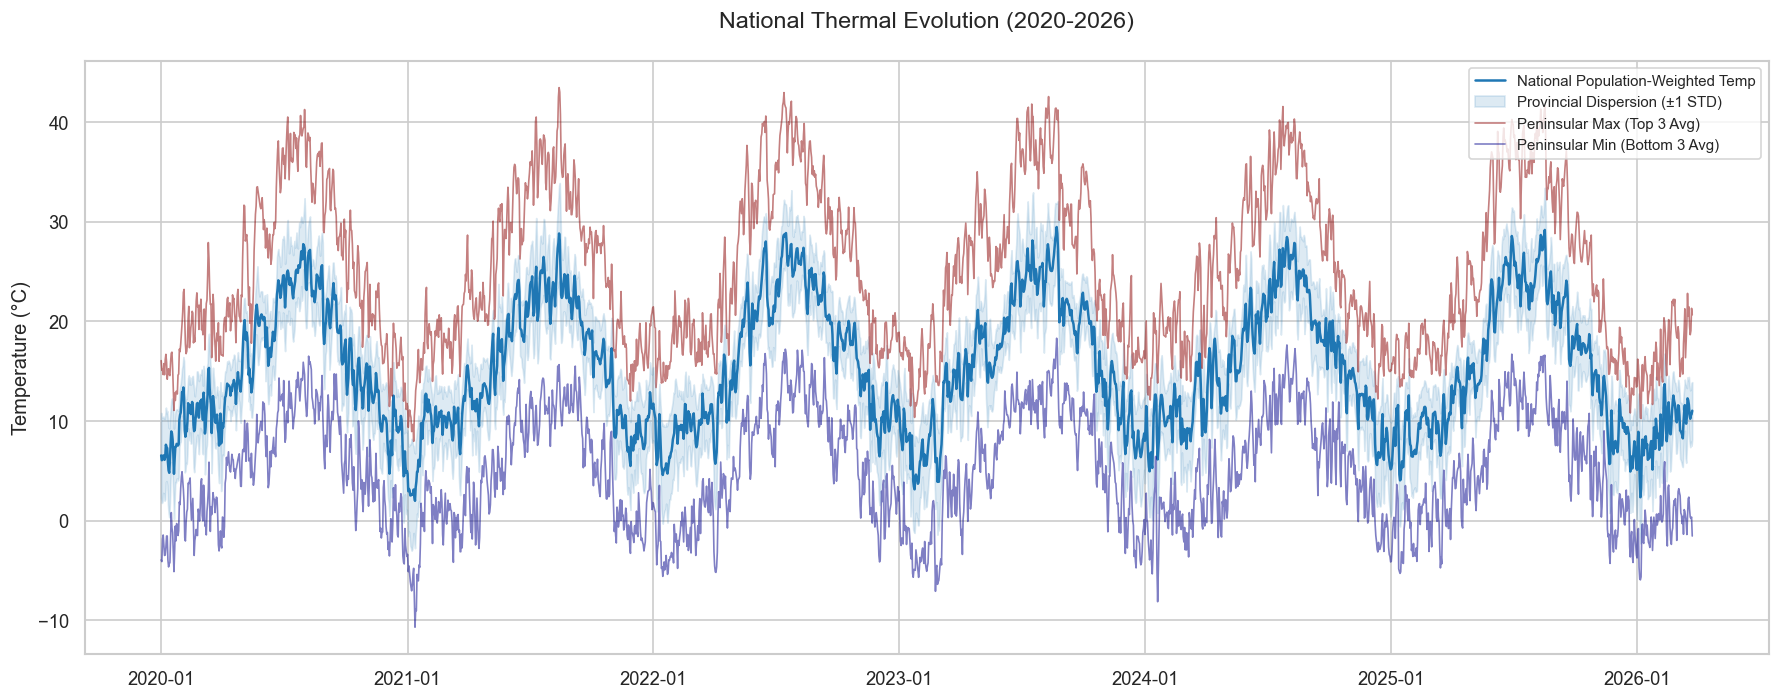

In [4]:
plt.figure(figsize=(15, 6))

# Plot weighted mean with dispersion area
plt.plot(df['date'], df['temperature_2m_mean'], color='#1f77b4', linewidth=1.5, label='National Population-Weighted Temp')
plt.fill_between(df['date'], 
                 df['temperature_2m_mean'] - df['std_avg_temperature'], 
                 df['temperature_2m_mean'] + df['std_avg_temperature'], 
                 color='#1f77b4', alpha=0.15, label='Provincial Dispersion (±1 STD)')

# Plot Robust Peninsular Extremes
plt.plot(df['date'], df['peninsular_max_temp'], color='darkred', alpha=0.5, linewidth=1, label='Peninsular Max (Top 3 Avg)')
plt.plot(df['date'], df['peninsular_min_temp'], color='darkblue', alpha=0.5, linewidth=1, label='Peninsular Min (Bottom 3 Avg)')

plt.title('National Thermal Evolution (2020-2026)', pad=20)
plt.ylabel('Temperature (°C)')
plt.legend(loc='upper right', frameon=True, fontsize=9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

## 3. Renewable Potential: Validating Supply Drivers

Spain's marginal electricity price often crashes during periods of high wind and solar penetration. By utilizing a **Surface-Weighted** aggregation, we accurately capture the meteorological state of the rural regions holding the majority of the country's renewable generation assets.

**Visual Analysis Key Points:**
* **Deterministic vs. Stochastic Profiles:** The dual-axis plot highlights two distinctly different supply-side behaviors. **Solar Radiation** (orange) is highly deterministic and seasonal, acting as a predictable baseload variance. Conversely, **Wind Speed** (teal) exhibits stochastic, high-frequency volatility, acting as the primary driver for sudden price drops and intra-day market shocks.

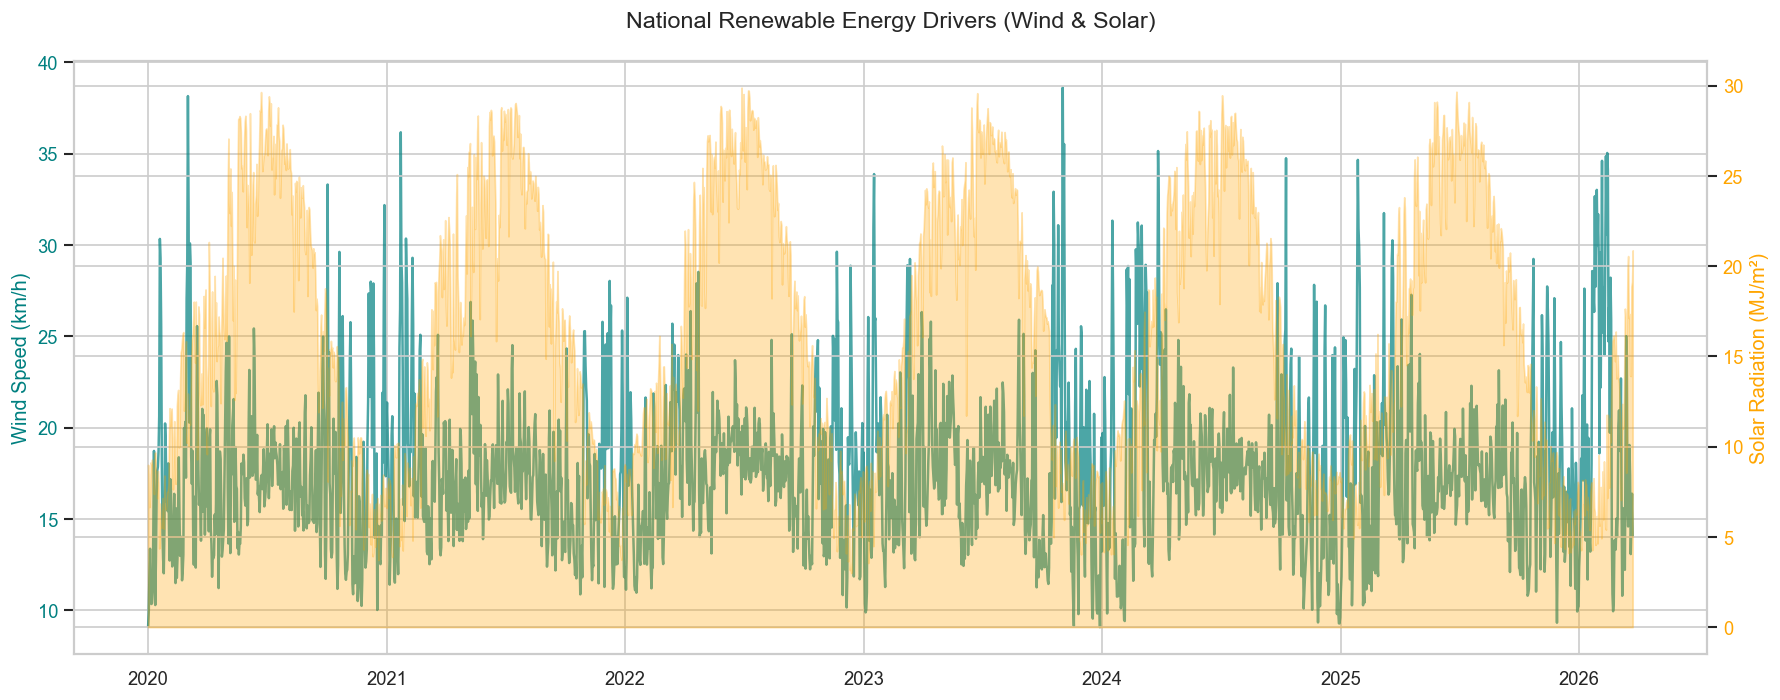

In [5]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# Wind Speed Axis
ax1.set_ylabel('Wind Speed (km/h)', color='teal')
ax1.plot(df['date'], df['wind_speed_10m_max'], color='teal', alpha=0.7, label='Surface-Weighted Wind Speed')
ax1.tick_params(axis='y', labelcolor='teal')

# Solar Radiation Axis
ax2 = ax1.twinx()
ax2.set_ylabel('Solar Radiation (MJ/m²)', color='orange')
ax2.fill_between(df['date'], df['shortwave_radiation_sum'], color='orange', alpha=0.3, label='Solar Radiation Sum')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('National Renewable Energy Drivers (Wind & Solar)', pad=20)
fig.tight_layout()
plt.show()

## 4. EDA Findings & Next Steps

### Key Observations:
1. **Validation of the Weighting Logic:** The dual-weighting strategy successfully smooths out localized sensor noise while perfectly preserving national systemic trends and major historical weather events.
2. **Predictive Capability:** The features exhibit the exact behaviors needed by the RL agent: distinct seasonality (Solar/Temp) combined with actionable volatility (Wind/Extremes).
3. **Data Integrity:** The aggregation engine has produced a continuous time series from 2020 to 2026 with no immediate gaps or visual anomalies in the macro-variables.

### Conclusion & Pipeline Transition:
The dataset is analytically valid and structurally sound. However, before merging this weather environment with our OMIP financial data, we must perform a final **Technical Cleaning** phase to ensure programmatic compatibility. This will involve:
* Enforcing strict integer casting for binary flags (e.g., National Holidays).
* Standardizing date indices and formatting to guarantee a perfect 1-to-1 temporal match during the financial join.
* Final algorithmic null-value verification.

**Next Pipeline Stage:** Execute `03_clean_weather.py`